# KNN Regression

In [1]:
%pip install ucimlrepo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')

## Importing the Dataset

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
abalone = fetch_ucirepo(id=1) 
  
# data (as pandas dataframes) 
X = abalone.data.features 
y = abalone.data.targets 
df_original = pd.concat([X, y], axis=1).copy()
  
# metadata 
print(abalone.metadata) 
  
# variable information 
print(abalone.variables) 


{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

In [4]:
display(X)

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550
...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960


## Data Preprocessing

In [5]:
X.isnull().sum()

,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0


In [6]:
y.isnull().sum()

,0
Rings,0


## Applying OneHot Encoder

In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first')
categorical_cols = ['Sex']
encoded_data = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_data.toarray(),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
 )
X = pd.concat([X.drop(columns=categorical_cols), encoded_df], axis=1)
display(X)

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,1.0,0.0
...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,0.0,0.0
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,0.0,1.0
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,0.0,1.0
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,0.0,0.0


## Splitting the Dataset

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2342)

## Applying Robust Scaler

In [9]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Training the Model

In [10]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error, r2_score
import joblib

class knn_regressor:
    def __init__(self, x_train, y_train, x_test, y_test, k):
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test
        self.k = k
        
        knn = neighbors.KNeighborsRegressor(n_neighbors=self.k, n_jobs=-1)
        knn.fit(self.x_train, self.y_train)
        
        self.y_pred = knn.predict(self.x_test)
        
        self.mse = mean_squared_error(self.y_test, self.y_pred)
        self.r2 = r2_score(self.y_test, self.y_pred)

    def getmetrics(self):
        return self.k, self.y_pred, self.mse, self.r2

In [11]:
k_list = range(1, 51)
train_df = pd.DataFrame(columns=['k', 'y_pred', 'MSE', 'R2', 'RMSE'])

trained_models = joblib.Parallel(n_jobs=-1, verbose=1)(
    joblib.delayed(knn_regressor)(X_train, y_train, X_test, y_test, k) for k in k_list
)

for model in trained_models:
    K, y_pred, mse, r2 = model.getmetrics()
    rmse = np.sqrt(mse)
    train_df = pd.concat([
        train_df,
        pd.DataFrame([[K, y_pred, mse, r2, rmse]], columns=['k', 'y_pred', 'MSE', 'R2', 'RMSE'])
    ], ignore_index=True)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed:    1.5s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    1.6s finished
/tmp/ipykernel_805/2292147661.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  train_df = pd.concat([


In [12]:
display(train_df)

,k,y_pred,MSE,R2,RMSE
0,1,"[[9.0], [12.0], [8.0], [14.0], [13.0], [8.0], ...",8.843301,0.205028,2.973769
1,2,"[[10.5], [9.5], [8.0], [12.5], [11.5], [7.5], ...",7.286782,0.344952,2.699404
2,3,"[[10.666666666666666], [9.0], [8.3333333333333...",6.510500,0.414736,2.551568
3,4,"[[10.0], [9.0], [8.25], [12.0], [11.5], [8.75]...",6.058239,0.455392,2.461349
4,5,"[[9.8], [9.0], [8.2], [11.4], [11.4], [8.4], [...",5.876220,0.471755,2.424092
5,6,"[[9.833333333333334], [9.333333333333334], [8....",5.912846,0.468462,2.431634
6,7,"[[9.714285714285714], [9.571428571428571], [8....",5.697271,0.487842,2.386896
7,8,"[[9.625], [9.375], [8.25], [11.25], [11.125], ...",5.658063,0.491366,2.378668
8,9,"[[9.666666666666666], [10.333333333333334], [8...",5.673814,0.489950,2.381977
9,10,"[[9.8], [10.1], [8.3], [10.8], [10.9], [9.1], ...",5.587667,0.497694,2.363825


## Plotting Outputs

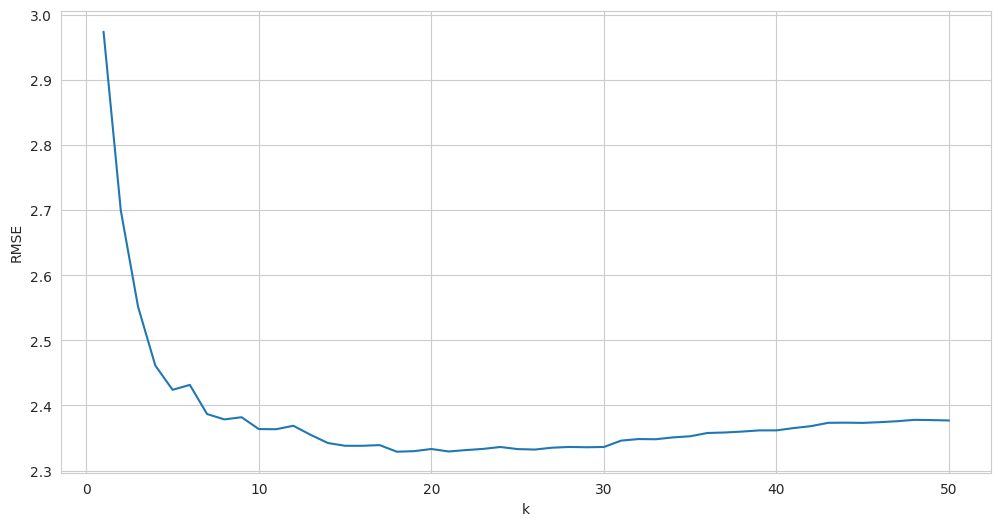

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=train_df, x='k', y='RMSE')
plt.show()

## Plotting the Pairplot

<Figure size 1200x600 with 0 Axes>

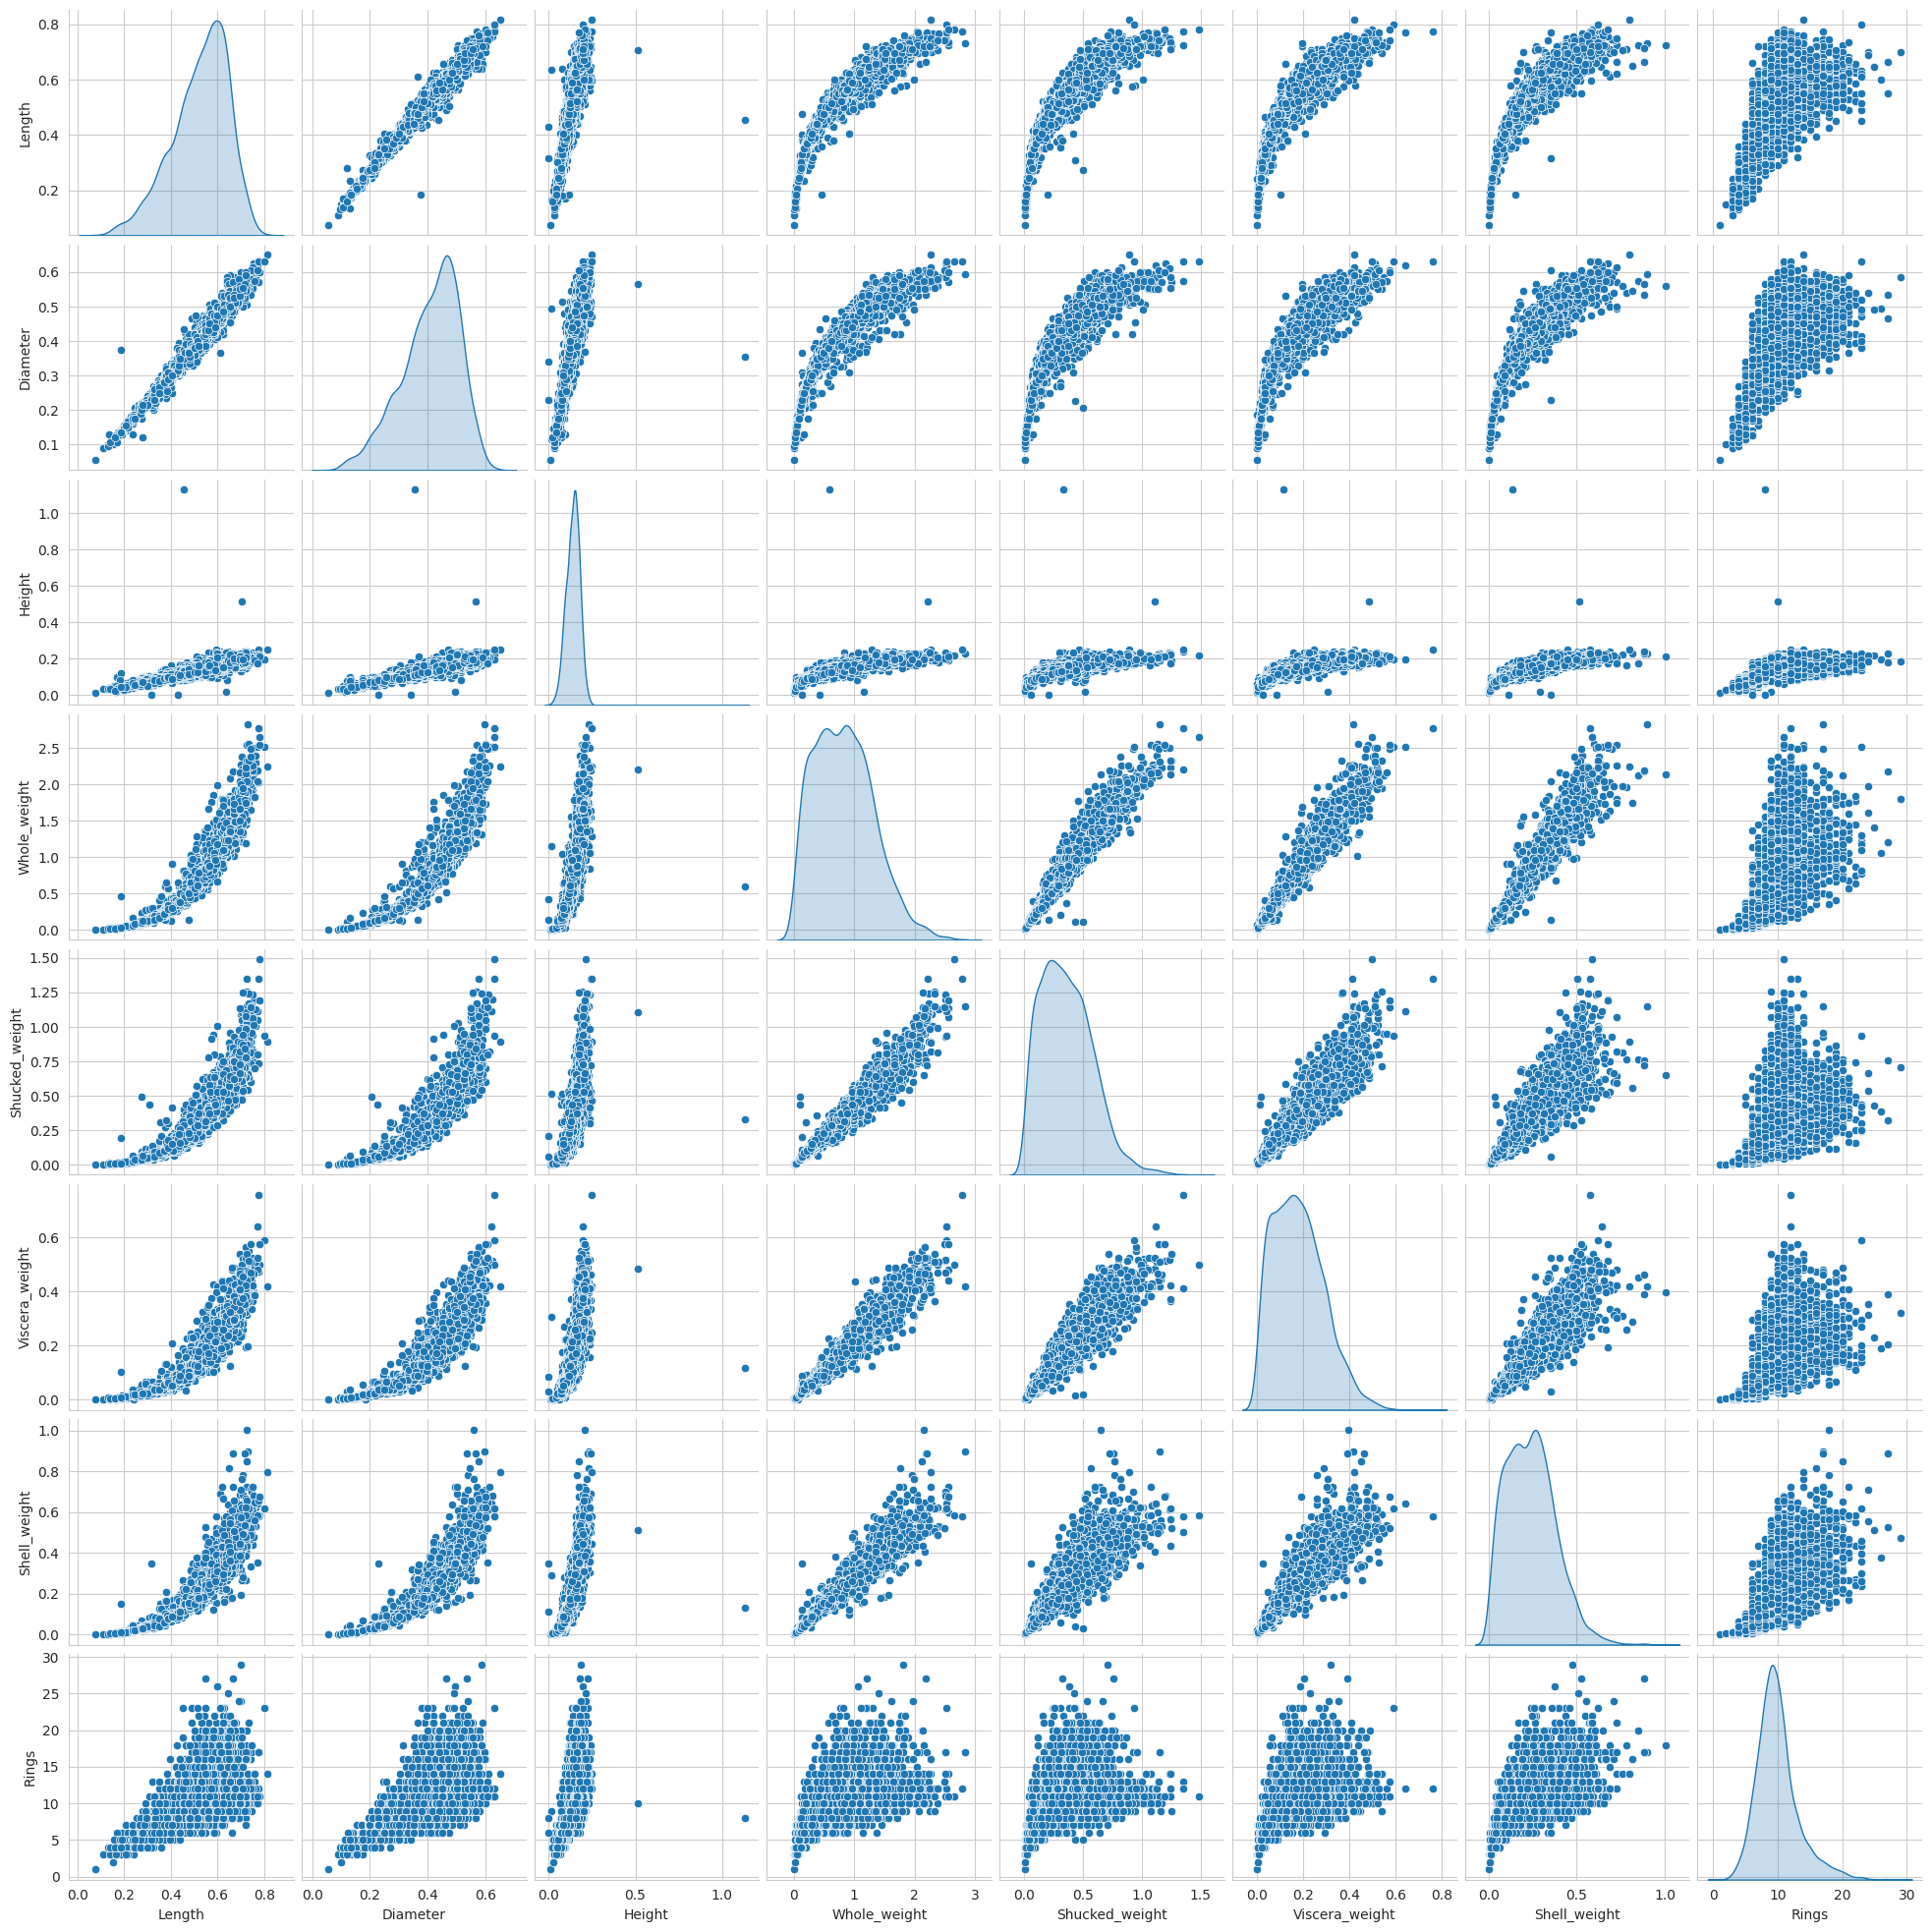

In [14]:
plt.figure(figsize=(12, 6))
sns.pairplot(df_original, diag_kind='kde')
plt.show()